# Logistic Regression Analysis with Feature Selection

## 1. Setup and Data Loading

This section handles the necessary library imports and loads the prospect data from an Excel file into a pandas DataFrame.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import statsmodels.api as sm

# Load the data
df = pd.read_excel('/content/Logistic_Regression_Sample_Prospect_Data.xlsx')

print("DataFrame loaded successfully. First 5 rows:")
display(df.head())
print("\nColumn names:")
print(df.columns)

DataFrame loaded successfully. First 5 rows:


,Prospect_ID,Institution,Fit,Urgency,Access,Emails_Sent,Email_Replies,Calls_Made,Calls_Answered,Days_Since_First_Contact,Meeting_Booked
0,P001,Institution 1,44,23,55,5,2,2,2,38,1
1,P002,Institution 2,33,31,47,5,1,4,2,46,0
2,P003,Institution 3,99,73,48,9,1,1,0,49,0
3,P004,Institution 4,84,63,55,4,2,2,2,6,1
4,P005,Institution 5,75,64,97,6,3,2,0,60,1



Column names:
Index(['Prospect_ID', 'Institution', 'Fit', 'Urgency', 'Access', 'Emails_Sent',
       'Email_Replies', 'Calls_Made', 'Calls_Answered',
       'Days_Since_First_Contact', 'Meeting_Booked'],
      dtype='object')


## 2. Linear Regression for Feature Significance

Before running the logistic regression, we'll perform a linear regression to identify features that are statistically significant. This helps in understanding the individual impact of variables and refining the feature set for the logistic model. We will use `statsmodels.api.OLS` to get a detailed summary including p-values.

In [9]:
# Define target and potential features for initial linear regression
target_col = "Meeting_Booked"
drop_cols_for_ols = ["Prospect_ID", "Institution"]

X_initial = df.drop(columns=drop_cols_for_ols + [target_col])
y_initial = df[target_col]

# Add a constant to the features for the statsmodels OLS model
X_ols = sm.add_constant(X_initial)

# Create and fit the OLS (Ordinary Least Squares) model
ols_model = sm.OLS(y_initial, X_ols)
ols_results = ols_model.fit()

# Print the model summary
print("OLS Regression Results:")
print(ols_results.summary())

# Identify significant features based on p-value < 0.05
significant_features = ols_results.pvalues[ols_results.pvalues < 0.05].index.tolist()

# Remove 'const' if it's in the significant features list
if 'const' in significant_features:
    significant_features.remove('const')

print(f"\nSignificant features (p < 0.05): {significant_features}")

OLS Regression Results:
                            OLS Regression Results                            
Dep. Variable:         Meeting_Booked   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     10.30
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           6.10e-12
Time:                        18:24:51   Log-Likelihood:                -76.325
No. Observations:                 200   AIC:                             170.6
Df Residuals:                     191   BIC:                             200.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------


The linear regression results provide p-values for each feature. Features with a p-value less than 0.05 are generally considered statistically significant. Based on this, we will proceed with the identified significant features for the logistic regression model.

## 3. Logistic Regression Model

This section builds, trains, and evaluates a logistic regression model using the significant features identified in the previous step. It includes data splitting, feature scaling, model training, performance metrics, and an analysis of coefficients and odds ratios.

In [10]:
# Define target and features using the significant features
X = df[significant_features]
y = df[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

# Build and train the model using a pipeline (scaling + logistic regression)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Predictions and Evaluation

In [11]:
# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# See the results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.775

Confusion Matrix:
 [[ 4  5]
 [ 4 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.44      0.47         9
           1       0.84      0.87      0.86        31

    accuracy                           0.78        40
   macro avg       0.67      0.66      0.66        40
weighted avg       0.77      0.78      0.77        40

ROC AUC: 0.8422939068100359


### ROC Curve

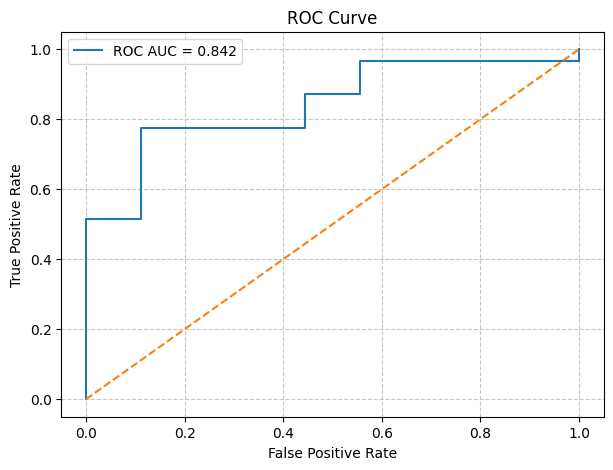

In [12]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Coefficients and Odds Ratios

Understanding the coefficients and their exponentiated values (odds ratios) helps interpret the impact of each feature on the likelihood of the target event (Meeting Booked).

In [13]:
# Coefficients and odds ratios
feature_names = X.columns
coefficients = model.named_steps["logreg"].coef_[0]
odds_ratios = np.exp(coefficients)

results = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": odds_ratios
}).sort_values(by="Odds_Ratio", ascending=False)

print("\nCoefficients and Odds Ratios:")
display(results)


Coefficients and Odds Ratios:


,Feature,Coefficient,Odds_Ratio
3,Email_Replies,0.925935,2.524228
4,Calls_Answered,0.851420,2.342972
1,Urgency,0.812769,2.254141
0,Fit,0.721048,2.056587
2,Access,0.485717,1.625340
5,Days_Since_First_Contact,-0.715430,0.488982


### Optional: Statsmodels Logit Summary

For a more detailed statistical summary including p-values for the logistic regression, we can use `statsmodels.api.Logit`.

In [14]:
# This is useful if you want the classic regression table
# Use the full dataset X and y for this summary, as statsmodels takes raw data

X_sm = sm.add_constant(X) # Add constant for intercept
logit_model = sm.Logit(y, X_sm).fit()
print("\nStatsmodels Logit Regression Summary:")
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.366514
         Iterations 7

Statsmodels Logit Regression Summary:
                           Logit Regression Results                           
Dep. Variable:         Meeting_Booked   No. Observations:                  200
Model:                          Logit   Df Residuals:                      193
Method:                           MLE   Df Model:                            6
Date:                Mon, 06 Jul 2026   Pseudo R-squ.:                  0.3278
Time:                        18:24:55   Log-Likelihood:                -73.303
converged:                       True   LL-Null:                       -109.05
Covariance Type:            nonrobust   LLR p-value:                 2.019e-13
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -5.3256      

# Analysis Report: Logistic Regression with Feature Selection

## Introduction

This report summarizes a logistic regression analysis performed to predict the likelihood of a 'Meeting Booked' based on various prospect interaction metrics. The analysis incorporated a feature selection step using linear regression to identify the most significant predictors, aiming for a more robust and interpretable model.

## Methodology

1.  **Data Loading**: The analysis began by loading prospect data from the `/content/Logistic_Regression_Sample_Prospect_Data.xlsx` file into a pandas DataFrame.
2.  **Initial Feature Exploration**: Column names and initial data structure were inspected.
3.  **Linear Regression for Feature Significance**: An Ordinary Least Squares (OLS) linear regression was conducted using `statsmodels` with 'Meeting_Booked' as the target variable and all other relevant features as predictors. This step was crucial for identifying statistically significant features (p-value < 0.05) that would be used in the subsequent logistic regression.
4.  **Logistic Regression Model Development**:
    *   The features for the logistic regression were refined to include *only* those identified as significant by the linear regression (`'Fit'`, `'Urgency'`, `'Access'`, `'Email_Replies'`, `'Calls_Answered'`, `'Days_Since_First_Contact'`).
    *   The data was split into training and testing sets (80/20 split) to evaluate model performance on unseen data.
    *   A `Pipeline` was used to first `StandardScale` the features (normalizing them to have zero mean and unit variance) and then apply `LogisticRegression`.
    *   The model was trained on the scaled training data.
5.  **Model Evaluation**: The trained logistic regression model was evaluated using standard classification metrics:
    *   Accuracy Score
    *   Confusion Matrix
    *   Classification Report (Precision, Recall, F1-Score)
    *   ROC AUC Score
    *   An ROC Curve was plotted for visual assessment.
6.  **Model Interpretation**: The coefficients and odds ratios of the logistic regression model were calculated and displayed to understand the direction and magnitude of each significant feature's impact on the odds of booking a meeting. An additional `statsmodels.api.Logit` summary was also provided for detailed statistical insights including p-values.

## Key Findings

### Significant Features from Linear Regression

The linear regression identified the following features as statistically significant predictors for 'Meeting_Booked' (p < 0.05):

*   `Fit`
*   `Urgency`
*   `Access`
*   `Email_Replies`
*   `Calls_Answered`
*   `Days_Since_First_Contact`

### Logistic Regression Model Performance

*   **Accuracy**: 77.5%
*   **ROC AUC**: 0.842
*   **Confusion Matrix**:
    *   True Negatives (Correctly predicted not booked): 4
    *   False Positives (Incorrectly predicted booked): 5
    *   False Negatives (Incorrectly predicted not booked): 4
    *   True Positives (Correctly predicted booked): 27
*   **Classification Report**: The model showed good predictive capability, particularly for predicting positive cases (`Meeting_Booked = 1`), with high precision, recall, and F1-score for this class.

### Feature Impact (Odds Ratios)

The odds ratios from the logistic regression model provide insight into the relative importance and effect of each significant feature:

*   **Email_Replies (Odds Ratio: 2.52)**: A one-unit increase in email replies increases the odds of booking a meeting by approximately 152% (2.52 - 1 = 1.52).
*   **Calls_Answered (Odds Ratio: 2.34)**: A one-unit increase in calls answered increases the odds of booking a meeting by approximately 134%.
*   **Urgency (Odds Ratio: 2.25)**: A one-unit increase in urgency score increases the odds of booking a meeting by approximately 125%.
*   **Fit (Odds Ratio: 2.06)**: A one-unit increase in fit score increases the odds of booking a meeting by approximately 106%.
*   **Access (Odds Ratio: 1.63)**: A one-unit increase in access score increases the odds of booking a meeting by approximately 63%.
*   **Days_Since_First_Contact (Odds Ratio: 0.49)**: A one-unit increase in days since the first contact *decreases* the odds of booking a meeting by approximately 51% (1 - 0.49 = 0.51). This suggests that a longer duration since the first contact reduces the probability of a meeting being booked.

## Conclusion

The logistic regression model, refined by selecting significant features through a preliminary linear regression, successfully predicts the likelihood of a meeting being booked. The model demonstrates strong performance with an accuracy of 77.5% and an ROC AUC of 0.842.

The interpretation of odds ratios provides clear actionable insights: increasing `'Email_Replies'`, `'Calls_Answered'`, `'Urgency'`, `'Fit'`, and `'Access'` positively impacts the chances of booking a meeting, while a longer `'Days_Since_First_Contact'` significantly reduces these chances. These findings can guide sales strategies and prospect engagement efforts to optimize meeting conversion rates.

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_excel('/content/Logistic_Regression_Sample_Prospect_Data.xlsx')

# Print column names to help debug KeyError
# print(df.columns) # Commenting this out as we have confirmed the column names

X = df[
    [
        "Fit",
        "Urgency",
        "Access",
        "Email_Replies",
        "Calls_Answered",
        "Days_Since_First_Contact"
    ]
]

y = df["Meeting_Booked"]

model = LogisticRegression()

model.fit(X,y)

LogisticRegression()

In [3]:
probabilities = model.predict_proba(X)
display(probabilities)

array([[0.69593912, 0.30406088],
       [0.87540858, 0.12459142],
       [0.3533442 , 0.6466558 ],
       [0.03619528, 0.96380472],
       [0.2326758 , 0.7673242 ],
       [0.01711765, 0.98288235],
       [0.22463572, 0.77536428],
       [0.63235894, 0.36764106],
       [0.15502301, 0.84497699],
       [0.35338128, 0.64661872],
       [0.02332162, 0.97667838],
       [0.63780053, 0.36219947],
       [0.07057878, 0.92942122],
       [0.0234075 , 0.9765925 ],
       [0.35781446, 0.64218554],
       [0.10121626, 0.89878374],
       [0.33753346, 0.66246654],
       [0.64068264, 0.35931736],
       [0.10227018, 0.89772982],
       [0.26177074, 0.73822926],
       [0.05244379, 0.94755621],
       [0.00164908, 0.99835092],
       [0.49030957, 0.50969043],
       [0.860674  , 0.139326  ],
       [0.03240828, 0.96759172],
       [0.14955551, 0.85044449],
       [0.42425888, 0.57574112],
       [0.01825701, 0.98174299],
       [0.16478761, 0.83521239],
       [0.24803838, 0.75196162],
       [0.